# Causal AI Fairness — Example 6

In this notebook, we reproduce **Example 5** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect the distributions of the effects in the case of a continuous Y variable

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [67]:
import sys
!{sys.executable} -m pip install daft-pgm

644.43s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [68]:
from pathlib import Path
import sys

import pandas as pd
from pgmpy.estimators import BayesianEstimator

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.sym.dsl import Variable
from src.sym.effects import symbolic_NDE, symbolic_total_effect
from src.visualisation.graph import visualize_sfm

REPO_ROOT

PosixPath('/Users/alessiaberarducci/Desktop/ale_causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [69]:
data_path = REPO_ROOT / "data" / "processed" / "adult.csv"
df = pd.read_csv(data_path)
selected_columns = [
    "hours-per-week",
    "occupation",
    "S2_gender",
]

df[selected_columns].head()


,hours-per-week,occupation,S2_gender
0,40,Machine-op-inspct,Male
1,50,Farming-fishing,Male
2,40,Protective-serv,Male
3,40,Machine-op-inspct,Male
4,30,Other,Female


In [70]:
df["occupation"].dtype
df["occupation"] = df["occupation"].astype("category")
df["S2_gender"].dtype
df["S2_gender"] = df["S2_gender"].astype("category")


In [71]:
df[selected_columns].nunique().rename("cardinality")

hours-per-week    96
occupation        15
S2_gender          2
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [72]:
private_attr = "S2_gender"
outcome_attr = "hours-per-week"
confounders = []
mediators = ["occupation"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_gender', 'hours-per-week'),
 ('S2_gender', 'occupation'),
 ('occupation', 'hours-per-week')]

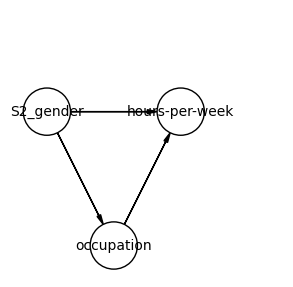

In [73]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [74]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()
bn

2026-03-10 17:09:32.841 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours-per-week': 'N', 'occupation': 'C', 'S2_gender': 'C'}


In [75]:
pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

S2_gender                                            [Female, Male]
hours-per-week    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
occupation        [Adm-clerical, Armed-Forces, Craft-repair, Exe...
Name: states, dtype: object

## 5. Compute core fairness effects

We evaluate the probability of the y outcome when comparing `Female` to `Male`.

We first compute the pointwise effects for each exact outcome level y. Then we take the cumulative sum over ordered y. 

In the end, we look at a specific $Y\leq y$


In [76]:
ys = sorted(df[outcome_attr].unique())


In [77]:
x0 = "Female"
x1 = "Male"
ys = sorted(df[outcome_attr].unique())

effects = []

for y in ys:
    target = (outcome_attr, y)

    effects.append(
        {
            "y": y,
            "TV": TV(bn, target, private_attr, x0, x1),
            "TE": TE(bn, target, private_attr, x0, x1),
            "NDE": DE(bn, target, private_attr, x0, x1),
            "NIE": IE(bn, target, private_attr, x1, x0),
        }
    )


effects = pd.DataFrame(effects).sort_values("y").reset_index(drop=True)

effects.round(4)

effects_cum = effects.copy()
cols = ["TV", "TE", "NDE", "NIE"]
effects_cum[cols] = effects_cum[cols].cumsum()

effects_cum.round(4)

2026-03-10 17:09:32.869 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('hours-per-week', np.int64(1)), private_baseline=Female, private_mod=Male
2026-03-10 17:09:32.874 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('hours-per-week', np.int64(2)), private_baseline=Female, private_mod=Male
2026-03-10 17:09:32.877 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('hours-per-week', np.int64(3)), private_baseline=Female, private_mod=Male
2026-03-10 17:09:32.880 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('hours-per-week', np.int64(4)), private_baseline=Female, private_mod=Male
2026-03-10 17:09:32.884 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('hours-per-week', np.int64(5)), private_baseline=Female, private_mod=Male
2026-03-10 17:09:32.888 | DEBUG    | src.effects:total_variation:247 - Computing tota

,y,TV,TE,NDE,NIE
0,1,-0.0006,-0.0006,-0.0004,0.0002
1,2,-0.0011,-0.0011,-0.0004,0.0007
2,3,-0.0022,-0.0022,-0.0011,0.0012
3,4,-0.0042,-0.0042,-0.0026,0.0016
4,5,-0.0063,-0.0063,-0.0041,0.0022
...,...,...,...,...,...
91,95,-0.0007,-0.0007,-0.0000,0.0007
92,96,-0.0008,-0.0008,-0.0002,0.0007
93,97,-0.0011,-0.0011,-0.0003,0.0008
94,98,-0.0010,-0.0010,-0.0003,0.0007


In [78]:
print(effects_cum.round(4).to_csv(sep="\t", index=False))

y	TV	TE	NDE	NIE
1	-0.0006	-0.0006	-0.0004	0.0002
2	-0.0011	-0.0011	-0.0004	0.0007
3	-0.0022	-0.0022	-0.0011	0.0012
4	-0.0042	-0.0042	-0.0026	0.0016
5	-0.0063	-0.0063	-0.0041	0.0022
6	-0.008	-0.008	-0.0051	0.0029
7	-0.009	-0.009	-0.0057	0.0033
8	-0.0135	-0.0135	-0.009	0.0045
9	-0.0143	-0.0143	-0.0092	0.005
10	-0.0197	-0.0197	-0.0125	0.0072
11	-0.0203	-0.0203	-0.0129	0.0074
12	-0.0254	-0.0254	-0.0165	0.0089
13	-0.0261	-0.0261	-0.0169	0.0092
14	-0.0274	-0.0274	-0.0175	0.0099
15	-0.0409	-0.0409	-0.0271	0.0138
16	-0.047	-0.047	-0.0322	0.0147
17	-0.0482	-0.0482	-0.0333	0.0149
18	-0.0504	-0.0504	-0.0346	0.0158
19	-0.0515	-0.0515	-0.0356	0.016
20	-0.0837	-0.0837	-0.0581	0.0256
21	-0.0851	-0.0851	-0.0591	0.0259
22	-0.0862	-0.0862	-0.0599	0.0263
23	-0.0876	-0.0876	-0.0611	0.0265
24	-0.094	-0.094	-0.0657	0.0283
25	-0.1111	-0.1111	-0.0783	0.0328
26	-0.1119	-0.1119	-0.0786	0.0332
27	-0.1131	-0.1131	-0.0796	0.0336
28	-0.1169	-0.1169	-0.0827	0.0342
29	-0.1177	-0.1177	-0.0833	0.0344
30	-0.1368	-0.1368

In [79]:
y_val = 40

results = (
    effects_cum[effects_cum["y"] == y_val]
    .assign(threshold=lambda d: "<=" + d["y"].astype(str))
    [["threshold","TV","TE","NDE","NIE"]]
)

results



,threshold,TV,TE,NDE,NIE
39,<=40,-0.178346,-0.178346,-0.140943,0.037403


## 6. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In this case we have no confounders, TV=TE. 

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.

In [80]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"].iloc[0],
        "NDE - NIE":  (results["NDE"] - results["NIE"]).iloc[0],
    },
)

decomposition_check_TE.round(10)

TE          -0.178346
NDE - NIE   -0.178346
dtype: float64